This file cleans the match history (all_matches.csv) by walking through each match chronologically, then calculates the needed features for every match before the result happens, and update the player stats after the result happens.

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

In [5]:
DATA_DIR = Path("../../data")
INPUT_FILE = DATA_DIR / "processed" / "all_matches.csv"
OUTPUT_FILE = DATA_DIR / "processed" / "model_train.csv"


In [10]:
df = pd.read_csv(INPUT_FILE)
df = df.drop(columns=df.columns[0])
df.head()

,match_id,season,date,seed_type,bastion_type,player_a_uuid,player_b_uuid,player_a_nickname,player_b_nickname,time,elo_a_before,elo_b_before,has_player_forfeited,winner_uuid
0,2803910,9,1755742042,RUINED_PORTAL,STABLES,185b039b70284aa9a98850db4ba88e0d,2ef2bfed3d084649b56290328970ace9,ElegantRobin,nahhann,562.592,1481,1651,False,185b039b70284aa9a98850db4ba88e0d
1,2803960,9,1755744563,DESERT_TEMPLE,HOUSING,253b53d832ab4bafb5ee0308d5164ccf,5ee577fdc1af45d3a6fb3e086cc293fb,Aquacorde,Ranik_,581.443,1574,1636,False,253b53d832ab4bafb5ee0308d5164ccf
2,2804064,9,1755745774,RUINED_PORTAL,BRIDGE,253b53d832ab4bafb5ee0308d5164ccf,78ea25c3db9a4830ba7e78074bd6fd10,Aquacorde,ogurikappa,443.339,1606,1646,True,253b53d832ab4bafb5ee0308d5164ccf
3,2804294,9,1755752305,VILLAGE,TREASURE,253b53d832ab4bafb5ee0308d5164ccf,939ddf85303441de901d60bfa4109318,Aquacorde,thecamo6,714.868,1582,1664,False,253b53d832ab4bafb5ee0308d5164ccf
4,2804359,9,1755753018,SHIPWRECK,TREASURE,2ef2bfed3d084649b56290328970ace9,253b53d832ab4bafb5ee0308d5164ccf,nahhann,Aquacorde,579.030,1630,1643,False,2ef2bfed3d084649b56290328970ace9


In [11]:
df.dtypes


match_id                  int64
season                    int64
date                      int64
seed_type                object
bastion_type             object
player_a_uuid            object
player_b_uuid            object
player_a_nickname        object
player_b_nickname        object
time                    float64
elo_a_before              int64
elo_b_before              int64
has_player_forfeited       bool
winner_uuid              object
dtype: object

In [12]:
# Filter out forfeited match
df = df[df["has_player_forfeited"] != True]

In [13]:
df.sort_values("time")

,match_id,season,date,seed_type,bastion_type,player_a_uuid,player_b_uuid,player_a_nickname,player_b_nickname,time,elo_a_before,elo_b_before,has_player_forfeited,winner_uuid
6423,3489002,9,1761876457,RUINED_PORTAL,HOUSING,a54e3bc4c6354b07a236b81efbcfe791,addd890764404097b3f12acdde2adf33,Infume,_Hypn0tic,347.271,2471,2032,False,a54e3bc4c6354b07a236b81efbcfe791
1691,2972056,9,1757378341,RUINED_PORTAL,HOUSING,9a8e24df4c8549d696a6951da84fa5c4,3b01d4b4fef14f178b75f05c04dd34ef,Feinberg,BeefSalad,366.383,1902,1990,False,3b01d4b4fef14f178b75f05c04dd34ef
8915,3943440,9,1764911051,RUINED_PORTAL,TREASURE,2ef2bfed3d084649b56290328970ace9,a54e3bc4c6354b07a236b81efbcfe791,nahhann,Infume,368.016,2292,2627,False,a54e3bc4c6354b07a236b81efbcfe791
8118,3732338,9,1763537785,RUINED_PORTAL,TREASURE,4aed1e5e8f5c44e2bc0666e0c03781af,ac601ce7376f49cea7ce14cd577dac85,nEmerald,BlazeMind,372.000,2127,2436,False,4aed1e5e8f5c44e2bc0666e0c03781af
3256,3115565,9,1758766011,RUINED_PORTAL,BRIDGE,3b01d4b4fef14f178b75f05c04dd34ef,9a8e24df4c8549d696a6951da84fa5c4,BeefSalad,Feinberg,374.515,2153,2284,False,3b01d4b4fef14f178b75f05c04dd34ef
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5915,3440377,9,1761445124,SHIPWRECK,STABLES,ba31689fe7d24431bf7997a52efcc21c,7665f76f431b41c6b321bea16aff913b,meebie,lowk3y_,1170.620,2066,2271,False,ba31689fe7d24431bf7997a52efcc21c
3911,3179216,9,1759291098,SHIPWRECK,STABLES,a0a672a0bc194540bc195220dc170dba,2fe70934e7be458dba747c4ac830391c,JackoWacko62,steezFemboy,1213.707,1946,2179,False,a0a672a0bc194540bc195220dc170dba
3397,3125995,9,1758861692,VILLAGE,TREASURE,2fe70934e7be458dba747c4ac830391c,a0a672a0bc194540bc195220dc170dba,steezFemboy,JackoWacko62,1223.571,2137,1830,False,2fe70934e7be458dba747c4ac830391c
5115,3313472,9,1760401623,BURIED_TREASURE,STABLES,388533d5a2ad4b349a31db4738670a4b,a54e3bc4c6354b07a236b81efbcfe791,v_strid,Infume,1241.580,2090,2479,False,a54e3bc4c6354b07a236b81efbcfe791


In [14]:
NOT_INCLUDED = ["match_id", "season", "date", "player_a_uuid", "player_b_uuid",
                "player_a_nickname", "player_b_nickname", "winner_uuid"]
df.columns[~df.columns.isin(NOT_INCLUDED)]

Index(['seed_type', 'bastion_type', 'time', 'elo_a_before', 'elo_b_before',
       'has_player_forfeited'],
      dtype='object')

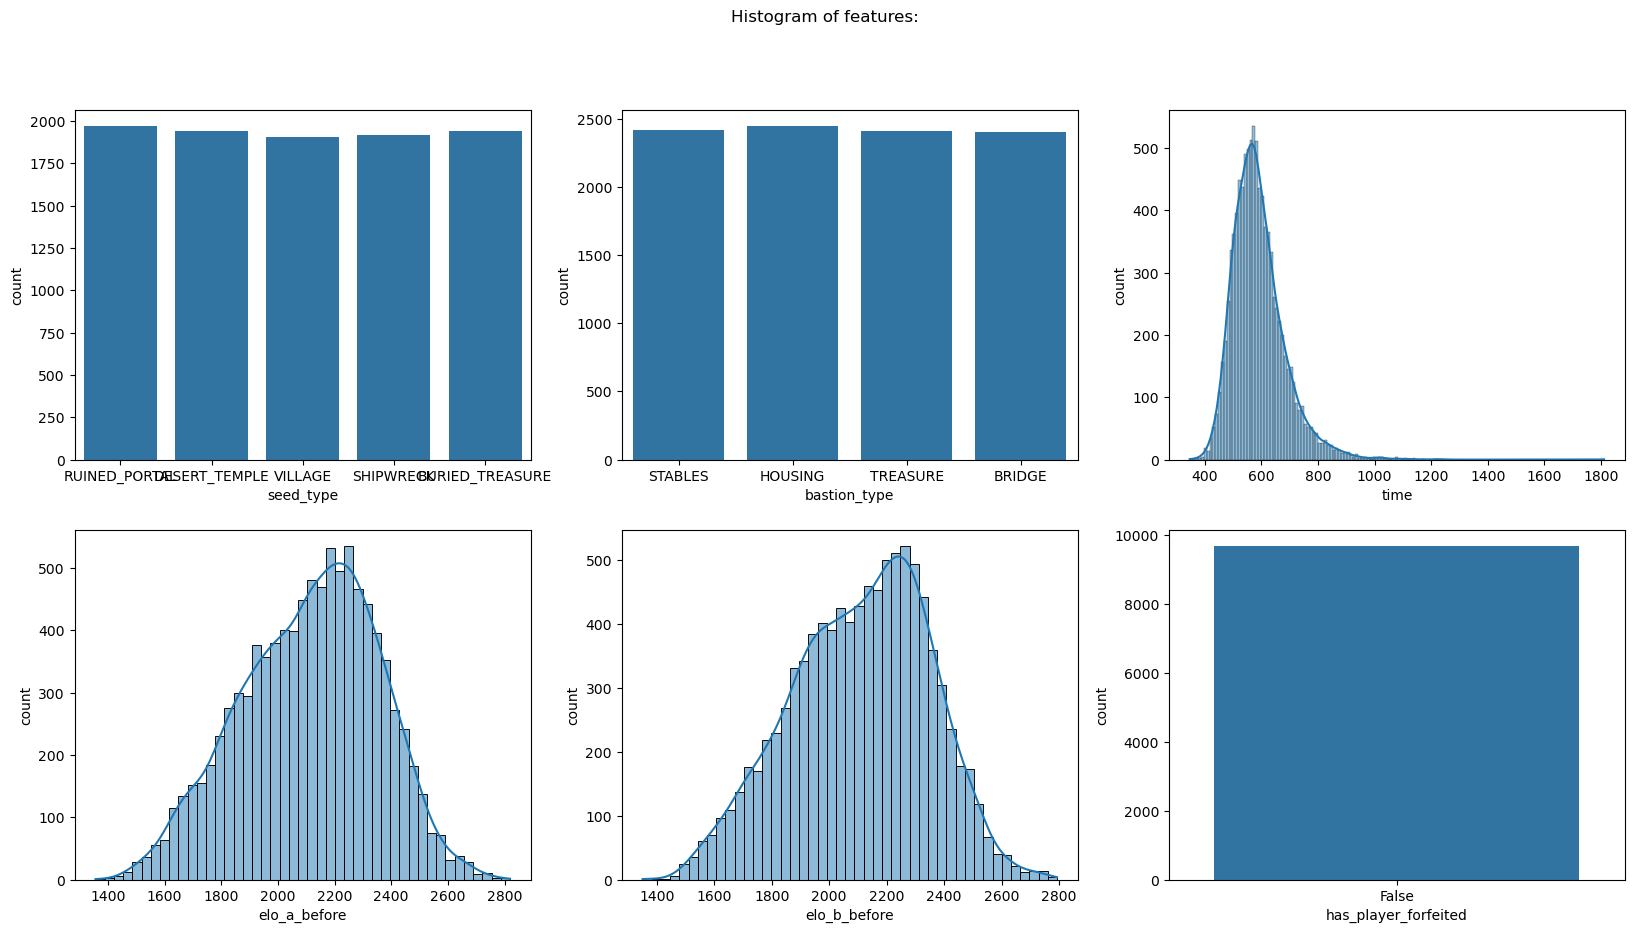

In [15]:
plt.figure(figsize=(20, 10))
for i, feature in enumerate(df.columns[~df.columns.isin(NOT_INCLUDED)]):
    plt.subplot(2, 3, i + 1)
    if df[feature].dtype in ["int64", "float64"]:
        sns.histplot(kde=True, data=df, x=feature)
    else:
        sns.countplot(data=df, x=feature)

    plt.xlabel(feature)
    plt.ylabel("count")

plt.suptitle("Histogram of features:")
plt.show()

In [16]:
def get_profile():
    """Initialize the profile of a player for metrics
    such as win streak + last results up to a certain time"""
    return {
        "matches_played": 0, #The current amount of matches a player has played
        "wins": 0, #The current amount of wins a player has winned
        "current_win_streak": 0, #The current win streak length
        "recent_times": [], #The last n (n = 10) completion times
        "last_10_results": [], #The list of Wins and Losses (1 = Win, 0 = Loss)
        "maps":  defaultdict(lambda: {"wins": 0,
                                    "played": 0})

    }

In [17]:
player_stats = defaultdict(get_profile)
training_samples = []

for i, row in df.iterrows():
    a_uuid = row['player_a_uuid']
    b_uuid = row['player_b_uuid']

    a_stats = player_stats[a_uuid]
    b_stats = player_stats[b_uuid]

    elo_diff = row['elo_a_before'] - row['elo_b_before'] #Elo diff
    streak_diff = a_stats['current_win_streak'] - b_stats['current_win_streak'] #Win streak diff

    #Std for consistency checking
    a_std = np.std(a_stats['recent_times']) if len(a_stats['recent_times']) >= 2 else 0
    b_std = np.std(b_stats['recent_times']) if len(b_stats['recent_times']) >= 2 else 0
    consistency_diff = a_std - b_std

    #Winrate last 10 games
    a_win_rate_10 = np.mean(a_stats['last_10_results']) if a_stats['last_10_results'] else 0.5
    b_win_rate_10 = np.mean(b_stats['last_10_results']) if b_stats['last_10_results'] else 0.5
    form_diff = a_win_rate_10 - b_win_rate_10

    # Win rate on maps
    current_map = row['seed_type']
    a_map_stats = a_stats["maps"][current_map]
    a_map_wr = a_map_stats['wins'] / a_map_stats['played'] if a_map_stats['played'] > 0 else 0.5

    b_map_stats = b_stats['maps'][current_map]
    b_map_wr = b_map_stats['wins'] / b_map_stats["played"] if b_map_stats["played"] > 0 else  0.5

    map_wr_diff = a_map_wr - b_map_wr
    #1 if a won, else 0
    a_win = 1 if row["winner_uuid"] == a_uuid else 0

    training_samples.append({
        "match_id": row["match_id"],
        "date": row["date"],
        "player_a_uuid": a_uuid,
        "player_b_uuid": b_uuid,
        "player_a_nickname": row["player_a_nickname"],
        "player_b_nickname": row["player_b_nickname"],
        "elo_diff": elo_diff,
        "map_wr_diff": map_wr_diff,
        "streak_diff": streak_diff,
        "consistency_diff": consistency_diff,
        "form_diff": form_diff,
        "std_a": a_std,
        "std_b": b_std,
        "overworld_type": row['seed_type'],
        "bastion_type": row["bastion_type"],
        "target": a_win})

    #Update player current stats after match
    a_stats["matches_played"], b_stats["matches_played"] = a_stats["matches_played"] + 1, b_stats["matches_played"] + 1
    a_stats['maps'][current_map]["played"] += 1
    b_stats['maps'][current_map]["played"] += 1
    if a_win == 1:
        a_stats['wins'] += 1
        a_stats['current_win_streak'] += 1
        b_stats['current_win_streak'] = 0
        a_stats['last_10_results'].append(1)
        b_stats['last_10_results'].append(0)
        a_stats["maps"][current_map]['wins'] += 1
    else:
        b_stats['wins'] += 1
        b_stats['current_win_streak'] += 1
        a_stats['current_win_streak'] = 0
        a_stats['last_10_results'].append(0)
        b_stats['last_10_results'].append(1)
        b_stats['maps'][current_map]['wins'] += 1


    a_stats['recent_times'].append(row['time'])
    b_stats["recent_times"].append(row['time'])

    #Keep only the last 10
    a_stats["recent_times"] = a_stats["recent_times"][-10:]
    b_stats["recent_times"] = b_stats["recent_times"][-10:]
    a_stats["last_10_results"] = a_stats["last_10_results"][-10:]
    b_stats["last_10_results"] = b_stats["last_10_results"][-10:]

train_df = pd.DataFrame(training_samples)
train_df.to_csv(OUTPUT_FILE, index=False)
train_df.head()

,match_id,date,player_a_uuid,player_b_uuid,player_a_nickname,player_b_nickname,elo_diff,map_wr_diff,streak_diff,consistency_diff,form_diff,std_a,std_b,overworld_type,bastion_type,target
0,2803910,1755742042,185b039b70284aa9a98850db4ba88e0d,2ef2bfed3d084649b56290328970ace9,ElegantRobin,nahhann,-170,0.0,0,0.0000,0.0,0.0,0.0000,RUINED_PORTAL,STABLES,1
1,2803960,1755744563,253b53d832ab4bafb5ee0308d5164ccf,5ee577fdc1af45d3a6fb3e086cc293fb,Aquacorde,Ranik_,-62,0.0,0,0.0000,0.0,0.0,0.0000,DESERT_TEMPLE,HOUSING,1
2,2804294,1755752305,253b53d832ab4bafb5ee0308d5164ccf,939ddf85303441de901d60bfa4109318,Aquacorde,thecamo6,-82,0.0,1,0.0000,0.5,0.0,0.0000,VILLAGE,TREASURE,1
3,2804359,1755753018,2ef2bfed3d084649b56290328970ace9,253b53d832ab4bafb5ee0308d5164ccf,nahhann,Aquacorde,-13,0.0,-2,-66.7125,-1.0,0.0,66.7125,SHIPWRECK,TREASURE,1
4,2804458,1755753995,3c8757790ab0400b8b9e3936e0dd535b,2e4fbe60568549f7a6666e1ced1ae385,doogile,R3nR,401,0.0,0,0.0000,0.0,0.0,0.0000,VILLAGE,BRIDGE,1
